In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import bartlett, chi2, spearmanr
from scipy.spatial.distance import pdist, squareform
from statsmodels.tsa.stattools import acf, pacf

import seaborn as sns
import statsmodels.api as sm
from scipy.stats import friedmanchisquare, linregress
from sklearn.ensemble import RandomForestRegressor


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
sensor = pd.read_csv("/content/drive/MyDrive/Complex Systems/sensor_hrv_filtered.csv")
sensor.head()

,deviceId,ts_start,ts_end,missingness_score,HR,ibi,acc_x_avg,acc_y_avg,acc_z_avg,grv_x_avg,...,calories,light_avg,sdnn,sdsd,rmssd,pnn20,pnn50,lf,hf,lf/hf
0,ab60,1617262425031,1617262724833,0.295448,84.592816,728.534374,0.284765,-0.593973,9.195984,-0.094203,...,0.000000,841.324415,89.363225,78.033038,98.417649,0.746269,0.391791,1818.065625,1252.992443,1.450979
1,ab60,1616736817151,1616737116986,0.239085,78.589565,781.896913,3.050179,-1.239353,5.790543,-0.211973,...,0.085083,486.485050,100.804974,73.468687,106.602933,0.803704,0.540741,1918.499169,2784.393293,0.689019
2,ab60,1616736517083,1616736816952,0.100773,75.620524,812.183910,2.153267,-3.546833,8.499866,-0.628970,...,NaN,779.033113,89.073518,48.675496,74.504896,0.809816,0.484663,1292.696555,1034.550027,1.249525
3,ab60,1616736217077,1616736516883,0.268178,85.813165,769.754943,2.898409,-3.401356,4.606113,-0.249247,...,1.375000,389.408638,102.371770,48.631219,70.615187,0.719178,0.400685,1561.785747,812.118619,1.923101
4,ab60,1616734416800,1616734716672,0.043466,76.944500,775.190053,-0.050221,-6.576164,5.377019,0.715893,...,0.000000,276.345515,84.045665,42.104491,66.973170,0.736111,0.450000,3460.217895,1886.157661,1.834533


In [19]:
def calculate_poincare_features(ibi_series):
    ibi_series = pd.Series(ibi_series).dropna()
    if len(ibi_series) < 2:
        return {"sd1": np.nan, "sd2": np.nan}

    # Calculate SD1 and SD2 based on the standard formulas
    diff_ibi = np.diff(ibi_series)
    sd1 = np.sqrt(0.5 * np.var(diff_ibi))
    sd2 = np.sqrt(2 * np.var(ibi_series) - 0.5 * np.var(diff_ibi))

    return {"sd1": sd1, "sd2": sd2}

results = []

for device_id, grp in sensor.groupby("deviceId"):
  grp_sorted = grp.sort_values("ts_start")
  series_ibi = grp_sorted["ibi"].dropna().values

  # Poincaré features (SD1 and SD2)
  poincare_features = calculate_poincare_features(series_ibi)

  # Extract average sdnn and rmssd
  average_sdnn = grp_sorted["sdnn"].mean()
  average_rmssd = grp_sorted["rmssd"].mean()

  # Saving the results
  results.append({
      "deviceID": device_id,
      "sd1": poincare_features["sd1"],
      "sd2": poincare_features["sd2"],
      "sdnn": average_sdnn,
      "rmssd": average_rmssd
  })
# Final dataframe containing SD1, SD2, SDNN, and RMSSD
df_fin = pd.DataFrame(results)

In [20]:
survey = pd.read_csv("/content/drive/MyDrive/Complex Systems/survey.csv")

# Check for significant difference between Timepoints of the survey scores
isi_res = friedmanchisquare(survey["ISI_1"], survey["ISI_2"], survey["ISI_F"])
phq9_res = friedmanchisquare(survey["PHQ9_1"], survey["PHQ9_2"], survey["PHQ9_F"])
gad7_res = friedmanchisquare(survey["GAD7_1"], survey["GAD7_2"], survey["GAD7_F"])

print(isi_res[1], phq9_res[1], gad7_res[1])

# None are significant so average
survey["ISI_avg"] = survey[["ISI_1", "ISI_2", "ISI_F"]].mean(axis=1)
survey["PHQ9_avg"] = survey[["PHQ9_1", "PHQ9_2", "PHQ9_F"]].mean(axis=1)
survey["GAD7_avg"] = survey[["GAD7_1", "GAD7_2", "GAD7_F"]].mean(axis=1)


survey = survey[["deviceId", "ISI_avg", "PHQ9_avg", "GAD7_avg"]]

0.8531469010211237 0.7070409693051646 0.11399031491931631


In [21]:
df_wide = df_fin.copy()

In [22]:
df_wide = df_wide.rename(columns={"deviceID": "deviceId"})
df_merged = survey.merge(df_wide, on="deviceId", how="inner")

In [23]:
df_merged.head()

,deviceId,ISI_avg,PHQ9_avg,GAD7_avg,sd1,sd2,sdnn,rmssd
0,pm96,8.000000,0.666667,0.333333,62.982298,146.112686,77.230083,77.092064
1,vc10,12.000000,2.666667,0.333333,78.467996,113.897897,66.415713,73.451173
2,pg18,10.666667,4.333333,2.333333,115.958822,217.634995,89.317783,100.562967
3,nd56,9.000000,4.333333,0.000000,40.057065,136.707236,66.427977,68.273967
4,vs14,13.666667,11.000000,8.333333,52.763630,122.206047,66.007012,71.744429


In [24]:
corr = df_merged.corr(method='spearman', numeric_only=True)

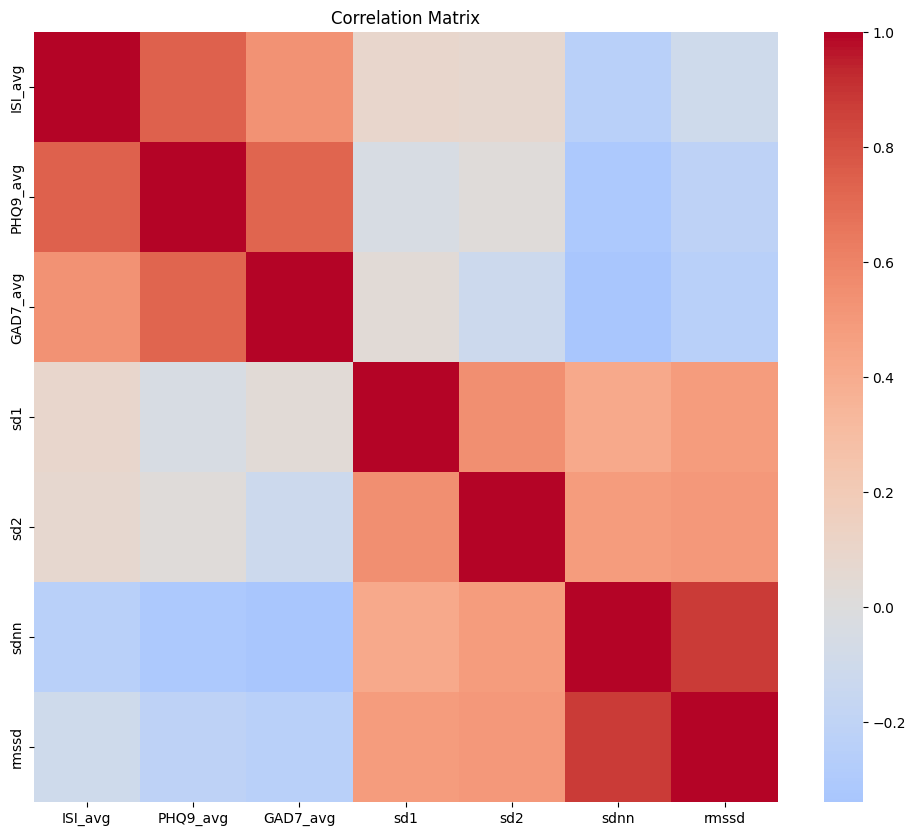

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## Random Forest Regression

In [26]:
X = df_merged[
    ["sd1", "sd2", "sdnn", "rmssd"]
]

### Random Forest Regressor Feature Importances for ISI_F (Insomnia)


In [27]:
# Calculating feature importances for ISI_F
y_isi = df_merged["ISI_avg"]
rf_isi = RandomForestRegressor(n_estimators=300, random_state=42)
rf_isi.fit(X, y_isi)
isi_importances_actual = pd.Series(rf_isi.feature_importances_, index=X.columns)
print("Feature Importances for ISI_F (Insomnia):\n", isi_importances_actual.sort_values(ascending=False))

Feature Importances for ISI_F (Insomnia):
 sdnn     0.308408
sd2      0.284598
sd1      0.229745
rmssd    0.177249
dtype: float64


### Random Forest Regressor Feature Importances for PHQ9_F (Depression)

In [28]:
y_phq9_actual = df_merged["PHQ9_avg"]
rf_phq9_actual = RandomForestRegressor(n_estimators=300, random_state=42)
rf_phq9_actual.fit(X, y_phq9_actual)
phq9_importances_actual = pd.Series(rf_phq9_actual.feature_importances_, index=X.columns)
print("Feature Importances for PHQ9_F (Depression):\n", phq9_importances_actual.sort_values(ascending=False))

Feature Importances for PHQ9_F (Depression):
 sdnn     0.333855
sd1      0.232918
sd2      0.219935
rmssd    0.213292
dtype: float64


### Random Forest Regressor Feature Importances for GAD7_F (Anxiety)

In [29]:
y_gad7_actual = df_merged["GAD7_avg"]
rf_gad7_actual = RandomForestRegressor(n_estimators=300, random_state=42)
rf_gad7_actual.fit(X, y_gad7_actual)
gad7_importances_actual = pd.Series(rf_gad7_actual.feature_importances_, index=X.columns)
print("Feature Importances for GAD7_F (Anxiety):\n", gad7_importances_actual.sort_values(ascending=False))

Feature Importances for GAD7_F (Anxiety):
 sdnn     0.338501
sd1      0.229042
rmssd    0.225375
sd2      0.207082
dtype: float64


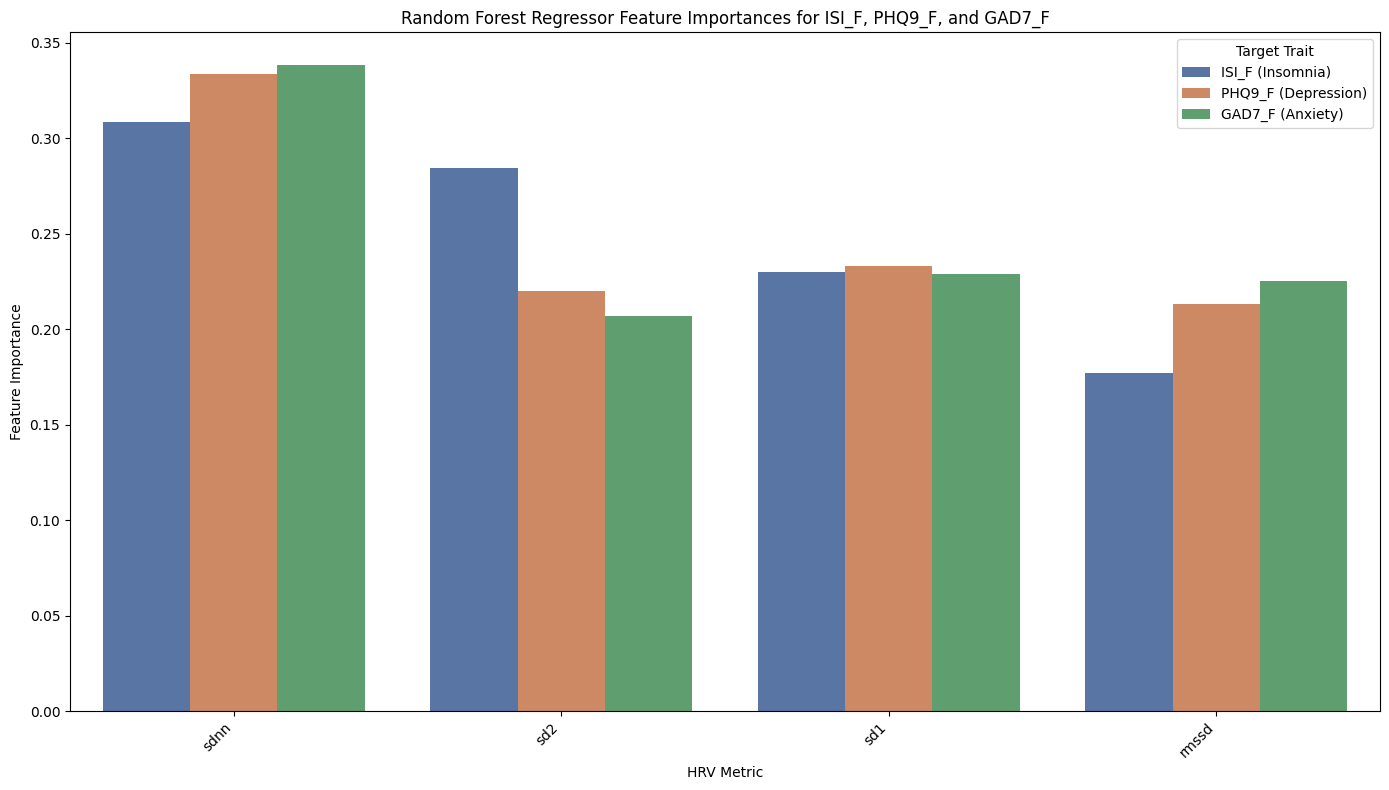

In [30]:
# Creating DataFrames for plotting
df_isi = pd.DataFrame({"Feature": isi_importances_actual.index, "Importance": isi_importances_actual.values, "Trait": "ISI_F (Insomnia)"})
df_phq9 = pd.DataFrame({"Feature": phq9_importances_actual.index, "Importance": phq9_importances_actual.values, "Trait": "PHQ9_F (Depression)"})
df_gad7 = pd.DataFrame({"Feature": gad7_importances_actual.index, "Importance": gad7_importances_actual.values, "Trait": "GAD7_F (Anxiety)"})

# Combining all dataframes
combined_importances = pd.concat([df_isi, df_phq9, df_gad7])

# Sorting features by overall importance for better visualization
sorted_features = combined_importances.groupby('Feature')['Importance'].mean().sort_values(ascending=False).index
combined_importances['Feature'] = pd.Categorical(combined_importances['Feature'], categories=sorted_features, ordered=True)

plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Importance', hue='Trait', data=combined_importances, palette='deep')
plt.title('Random Forest Regressor Feature Importances for ISI_F, PHQ9_F, and GAD7_F')
plt.xlabel('HRV Metric')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Target Trait')
plt.tight_layout()
plt.show()

### Scatterplots for each trait

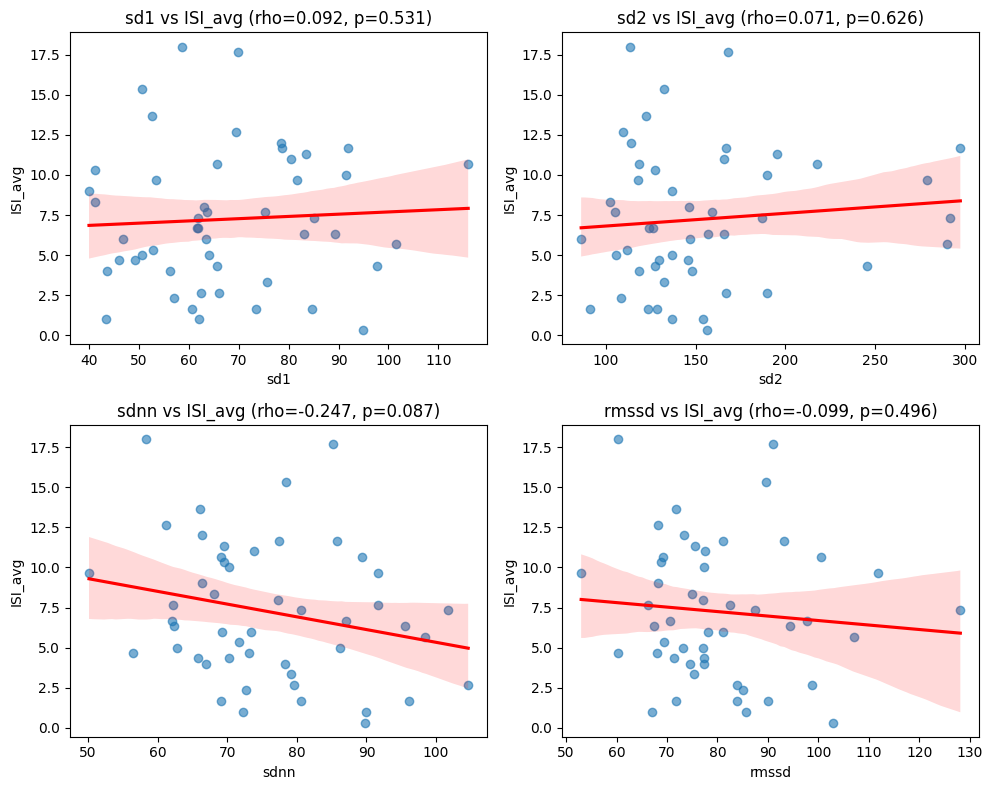

In [35]:
# Insomnia (ISI_F)
metrics = [
    "sd1", "sd2", "sdnn", "rmssd"
]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, m in enumerate(metrics):
    # Calculate Spearman correlation and get rho and p-value
    rho, p_value = spearmanr(df_merged[m].dropna(), df_merged["ISI_avg"].dropna())

    sns.regplot(
        data=df_merged,
        x=m,
        y="ISI_avg",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs ISI_avg (rho={rho:.3f}, p={p_value:.3f})")
plt.tight_layout()
plt.show()

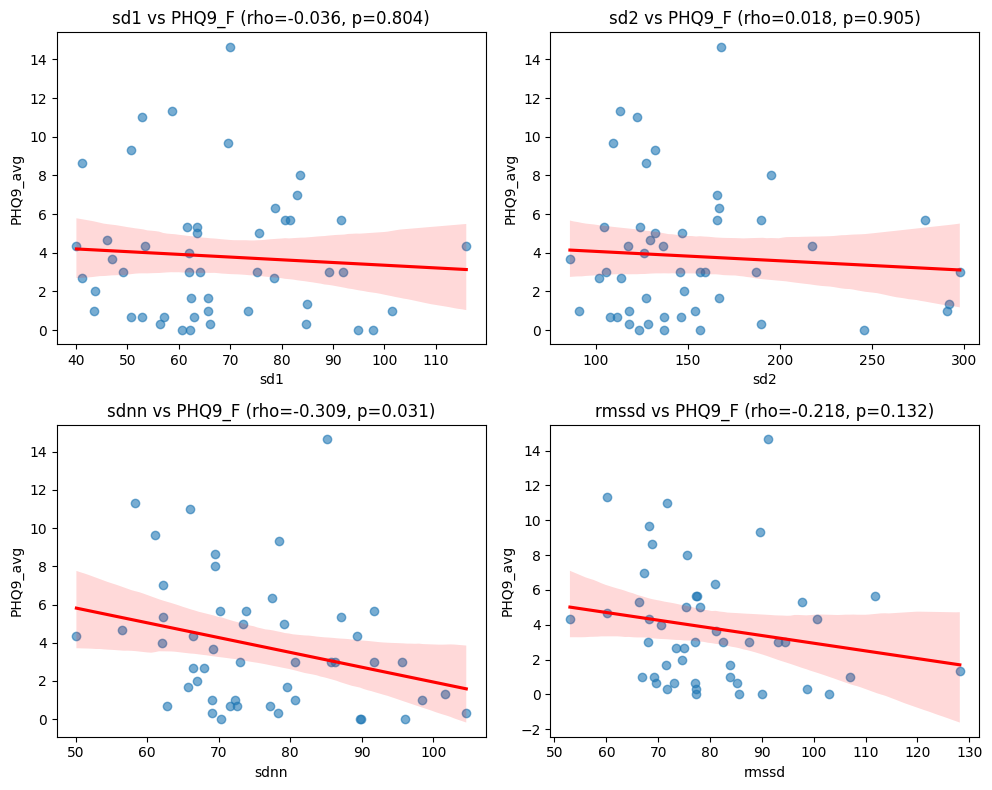

In [36]:
# Depression (PHQ9_F)
metrics = [
    "sd1", "sd2", "sdnn", "rmssd"
]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, m in enumerate(metrics):
    # Calculate Spearman correlation and get rho and p-value
    rho, p_value = spearmanr(df_merged[m].dropna(), df_merged["PHQ9_avg"].dropna())

    sns.regplot(
        data=df_merged,
        x=m,
        y="PHQ9_avg",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs PHQ9_F (rho={rho:.3f}, p={p_value:.3f})")
plt.tight_layout()
plt.show()

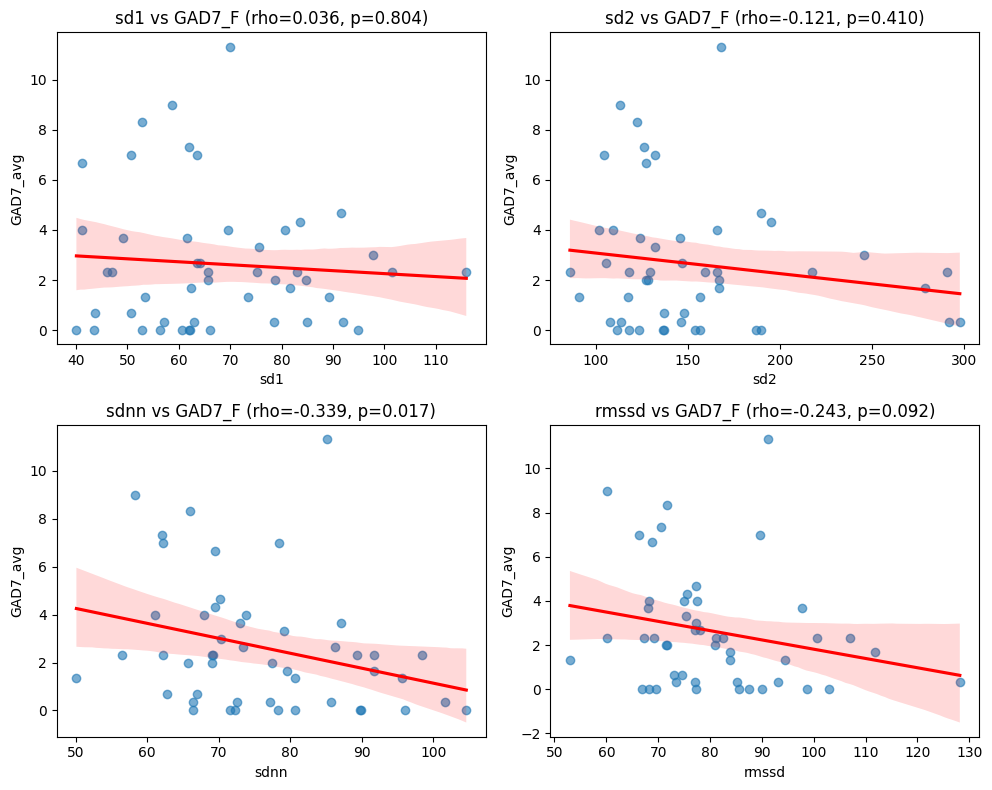

In [37]:
# Anxiety (GAD7_F)
metrics = [
    "sd1", "sd2", "sdnn", "rmssd"
]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, m in enumerate(metrics):
    # Calculate Spearman correlation and get rho and p-value
    rho, p_value = spearmanr(df_merged[m].dropna(), df_merged["GAD7_avg"].dropna())

    sns.regplot(
        data=df_merged,
        x=m,
        y="GAD7_avg",
        scatter_kws={"alpha":0.6},
        line_kws={"color":"red"},
        ax=axes[i]
    )
    axes[i].set_title(f"{m} vs GAD7_F (rho={rho:.3f}, p={p_value:.3f})")
plt.tight_layout()
plt.show()